# **Policy Assistant Using RAG & HuggingFace**

Built an AI-powered question-answering system designed to help employees instantly find answers from company policy documents. Instead of manually searching through pages of text, employees can simply type a question and get a clear, accurate answer in seconds.

To make this work, combined two powerful techniques — retrieval and generation. First, the system searches through the documents to find the most relevant paragraphs using Facebook's Dense Passage Retriever (DPR) and FAISS for fast similarity search. Then, it feeds those paragraphs into GPT-2, which generates a natural, readable answer based on the retrieved content.

Built the full pipeline from scratch — loading and preprocessing the documents, encoding them into vector embeddings, indexing them for fast search, and finally connecting everything to the GPT-2 generator. The result is a system that gives grounded, document-backed answers rather than relying on what the AI already knows, making it far more accurate and trustworthy for domain-specific use cases.

### **Import Libraries**


In [41]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from sklearn.manifold import TSNE
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import DPRContextEncoder, DPRContextEncoderTokenizer, DPRQuestionEncoder, DPRQuestionEncoderTokenizer
import wget

### Load Dataset 

In [2]:
file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/6JDbUb_L3egv_eOkouY71A.txt'

In [4]:
filename = "d:/Projects/rag-policy-assistant/files/company_policies.txt"
wget.download(file_url, out = filename)


'd:/Projects/rag-policy-assistant/files/company_policies.txt'

##### Pre-process Data

In [15]:
def data_preprocess (filename):
    
    with open (filename, "r") as file:
        text = file.read()
    
    paragraphs = text.split('\n')
    
    paragraph_list = [para.strip() for para in paragraphs if len(para.strip())> 0]
    
    return paragraph_list

In [22]:
policy_list = data_preprocess(filename=filename)
sample_list = policy_list[0:3]

In [23]:
sample_list

['1.\tCode of Conduct',
 'Our Code of Conduct outlines the fundamental principles and ethical standards that guide every member of our organization. We are committed to maintaining a workplace that is built on integrity, respect, and accountability.',
 'Integrity: We hold ourselves to the highest ethical standards. This means acting honestly and transparently in all our interactions, whether with colleagues, clients, or the broader community. We respect and protect sensitive information, and we avoid conflicts of interest.']

## Building the Retriever: Encoding and Indexing

Computers can't understand raw text directly — they work with numbers. So the first step is converting each paragraph into a list of numbers called a **vector embedding**. These vectors capture the meaning of the text, making it possible to compare paragraphs and find the ones most relevant to a user's question.

In this section, we encode all the paragraphs into vector embeddings and store them in a **FAISS index** — a tool that lets us search through thousands of vectors very quickly to find the best matches for any given query.

## Encoding Texts into Embeddings

To encode the paragraphs, we use the **Dense Passage Retriever (DPR)** model, specifically its context encoder. DPR is built on top of BERT but trained differently — instead of handling general NLP tasks, it is trained specifically to retrieve relevant passages by learning which documents best match a given question. This makes it much better at capturing the kind of meaning that matters for search and retrieval, compared to using a general-purpose BERT model.

In [18]:
model_name = "facebook/dpr-ctx_encoder-single-nq-base"

In [20]:
# context tokenizer
context_tokenizer = DPRContextEncoderTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Vish\.cache\huggingface\hub\models--facebook--dpr-ctx_encoder-single-nq-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [21]:
context_tokenizer

DPRContextEncoderTokenizer(name_or_path='facebook/dpr-ctx_encoder-single-nq-base', vocab_size=30522, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [24]:
sample_tokens = context_tokenizer(sample_list, return_tensors='pt', padding=True, truncation=True, max_length=256)
sample_tokens

{'input_ids': tensor([[  101,  1015,  1012,  3642,  1997,  6204,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101,  2256,  3642,  1997,  6204, 22106,  1996,  8050,  6481,  1998,
         12962,  4781,  2008,  5009,  2296,  2266,  1997,  2256,  3029,  1012,
          2057,  2024,  5462,  2000,  8498,  1037, 16165,  2008,  2003,  2328,
          2006, 11109,  1010,  4847,  1010,  1998, 17842,  1012,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101, 11109,  1024,  2057,  2907,  9731,  2000,  1996,  3284, 12962,
          4781,  1012,  2023,  2965,  3772,  9826,  1998, 13338,  2135,  1999,
          2035,  2256, 10266,  1010,

In [25]:
for text in sample_tokens.input_ids:
    output_text = context_tokenizer.convert_ids_to_tokens(text)
    print(output_text)

['[CLS]', '1', '.', 'code', 'of', 'conduct', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'our', 'code', 'of', 'conduct', 'outlines', 'the', 'fundamental', 'principles', 'and', 'ethical', 'standards', 'that', 'guide', 'every', 'member', 'of', 'our', 'organization', '.', 'we', 'are', 'committed', 'to', 'maintaining', 'a', 'workplace', 'that', 'is', 'built', 'on', 'integrity', ',', 'respect', ',', 'and', 'accountability', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'integrity', ':', 'we', 'hold', 'ourselves', 'to', 'the', 'highest', 'ethical', 'standards',

### Context Embedding
**2. Encoding**: Once the text is tokenized, it is passed into the `context_encoder`. The model reads through the tokens and compresses the entire meaning of the text into a single dense vector — think of it as a compact numerical summary that captures what the paragraph is really about.

The `DPRContextEncoder` is built on the same foundation as BERT but trained for a different purpose. While BERT is a general-purpose language model designed to handle a wide range of NLP tasks, DPR is trained specifically to match questions with relevant passages. It learns this through **contrastive learning** — a training approach where the model is taught to pull relevant question-passage pairs closer together in vector space and push unrelated ones further apart. This makes DPR far more effective at retrieval tasks than a standard BERT model.

In [26]:
context_encoder = DPRContextEncoder.from_pretrained(model_name)
context_encoder

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] DPRContextEncoder LOAD REPORT from: facebook/dpr-ctx_encoder-single-nq-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
ctx_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 
ctx_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DPRContextEncoder(
  (ctx_encoder): DPREncoder(
    (bert_model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bia

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [28]:
# shuffle samples
random.seed = 42
random.shuffle(policy_list)
random.shuffle(sample_list)

In [ ]:
output_sample = context_encoder(**sample_tokens)
output_sample

DPRContextEncoderOutput(pooler_output=tensor([[ 0.9058,  0.1277, -0.0524,  ..., -0.3109, -0.0634,  0.1343],
        [ 0.8406,  0.6897,  0.0202,  ..., -0.4066,  0.0511,  0.3425],
        [ 0.8745,  0.6094, -0.1193,  ..., -0.0681, -0.1915,  0.0144]],
       grad_fn=<SelectBackward0>), hidden_states=None, attentions=None)

In [31]:
output_sample.pooler_output, output_sample.pooler_output.shape

(tensor([[ 0.9058,  0.1277, -0.0524,  ..., -0.3109, -0.0634,  0.1343],
         [ 0.8406,  0.6897,  0.0202,  ..., -0.4066,  0.0511,  0.3425],
         [ 0.8745,  0.6094, -0.1193,  ..., -0.0681, -0.1915,  0.0144]],
        grad_fn=<SelectBackward0>),
 torch.Size([3, 768]))

### **Context Embedding Function**

In [39]:
def context_embeddings(text_list):
    embeddings = []
    for text in text_list:
        tokens = context_tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=256)
        output_embeddings = context_encoder(**tokens)
        outputs = output_embeddings.pooler_output
        
        embeddings.append(outputs)
    return torch.cat(embeddings).detach().numpy()
    

In [40]:
policy_embeddings = context_embeddings(policy_list)
policy_embeddings

array([[ 0.17804609,  0.5351761 ,  0.55847096, ..., -0.60847646,
        -0.83044916, -0.17659123],
       [ 0.5982949 ,  0.3699832 ,  0.6133506 , ..., -0.29540408,
        -0.47808248,  0.32521054],
       [ 0.3496334 ,  0.03431789, -0.12119062, ..., -0.13978037,
        -0.5199421 ,  0.05811717],
       ...,
       [ 0.6987652 ,  0.35299185, -0.20902517, ..., -0.12730163,
        -0.3183356 , -0.41821343],
       [ 0.7579645 ,  0.5367609 ,  0.06447412, ..., -0.32965466,
        -0.06132501,  0.35504448],
       [ 0.75075555,  0.5643831 , -0.03840955, ..., -0.5872765 ,
        -0.27589267,  0.02305413]], shape=(76, 768), dtype=float32)

##### Plot the T-Sne Distribution

In [48]:
def plot_tsne(data):
    
    tsne = TSNE(n_components=3, perplexity=data.shape[0]-1, random_state=42)
    data_3d = tsne.fit_transform(data)
    
    #plot the graphs
    fig= plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')
    
    #assign color for each data points based on thier index
    num_points = len(data_3d)
    colors = plt.cm.tab20(np.linspace(0,1,num_points))
    
    for idx, point in enumerate(data_3d):
        ax.scatter(point[0], point[1], point[2], label = str(idx), color = colors[idx])
    
    ax.set_xlabel('TSNE Component 1')
    ax.set_ylabel('TSNE Component 2')
    ax.set_zlabel('TSNE Component 3')
    plt.title('3D t-SNE Visualization')
    plt.legend(title='Input Order')
    plt.show()    

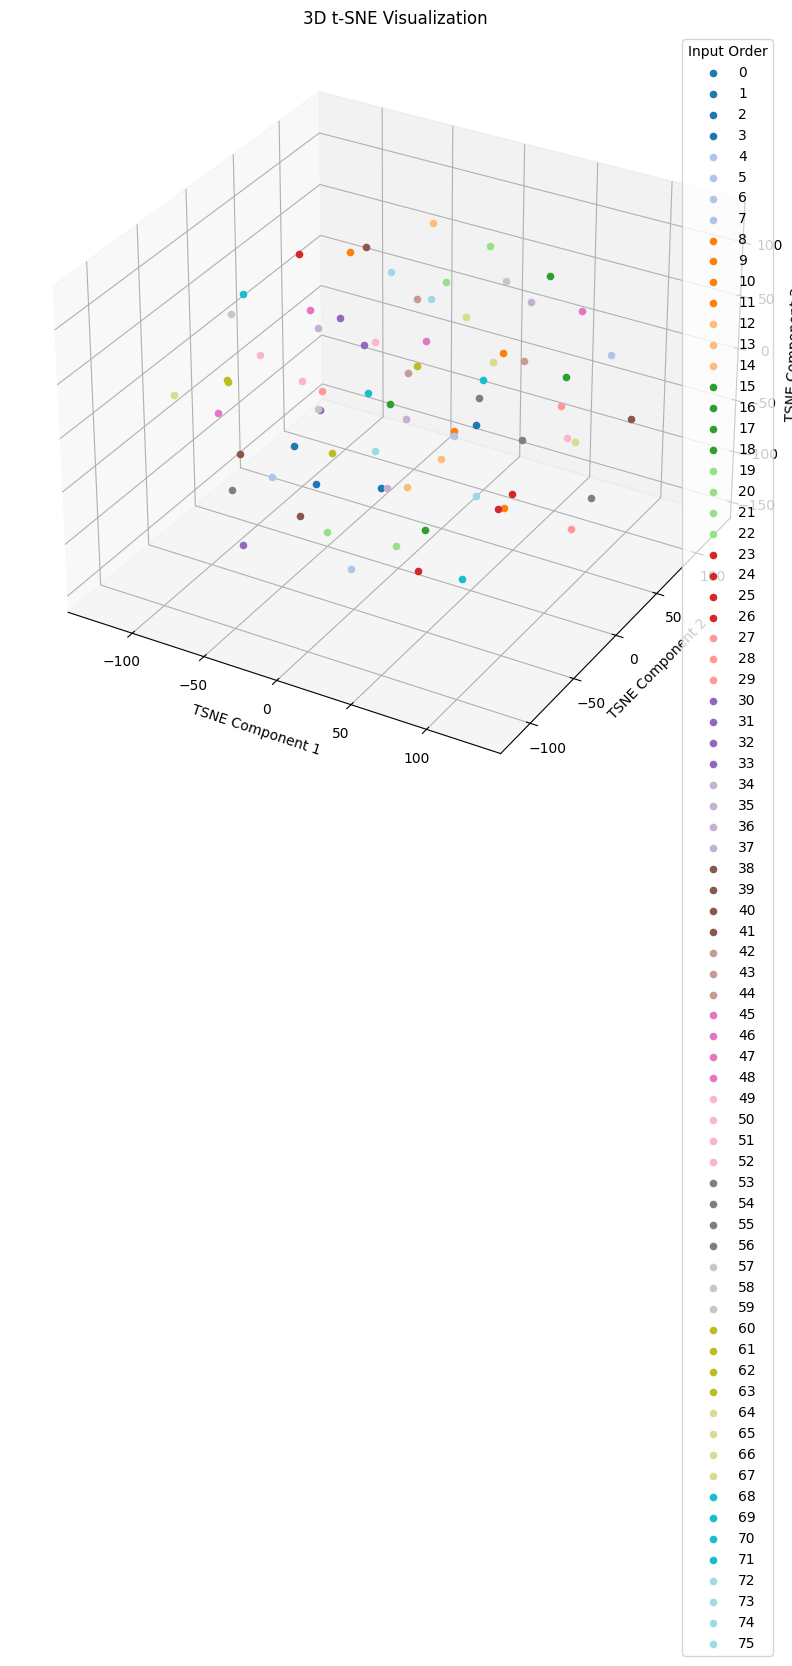

In [49]:
plot_tsne(policy_embeddings)